In [122]:
import os, shutil, pathlib
import random

import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

In [123]:
IMG_SIZE = (224, 224)

train_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=8
)

val_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=8
)

test_ds = keras.utils.image_dataset_from_directory(
    "hunt_dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=8
)

Found 118 files belonging to 2 classes.
Found 24 files belonging to 2 classes.
Found 27 files belonging to 2 classes.


In [124]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3))
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [125]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_ds)
val_features, val_labels = get_features_and_labels(val_ds)
test_features, test_labels = get_features_and_labels(test_ds)

train_features.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(118, 7, 7, 512)

In [126]:
inputs = keras.Input(shape=(7, 7, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(300)(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_features, train_labels,
    epochs=20,
    validation_data=(val_features, val_labels),
    callbacks=callbacks)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4831 - loss: 58.8917 - val_accuracy: 0.6667 - val_loss: 77.4883
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 944ms/step - accuracy: 0.8051 - loss: 23.3469 - val_accuracy: 0.7500 - val_loss: 31.9071
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.9153 - loss: 8.8967 - val_accuracy: 0.7917 - val_loss: 42.1004
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9576 - loss: 4.4806 - val_accuracy: 0.7917 - val_loss: 30.0817
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.8750 - val_loss: 25.6000
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 1.0000 - loss: 4.1466e-32 - val_accuracy: 0.8333 - val_loss: 26.9777
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 1.0000 - loss: 1.7161e-13 - val_accuracy: 0.8333 - val_loss: 29.3983
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 1.0000 - loss: 3.8277e-10 - val_accuracy: 0.

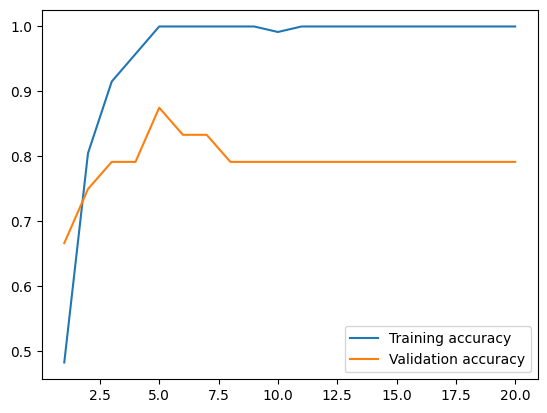

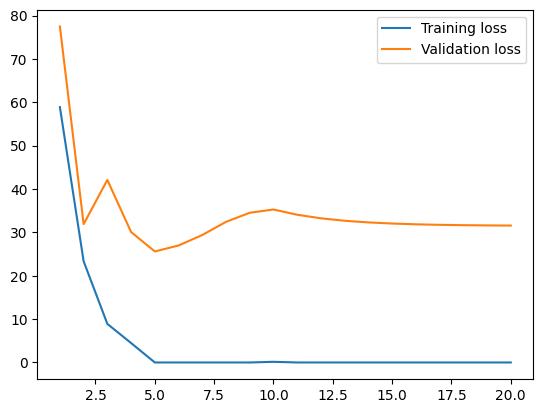

In [127]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [128]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - accuracy: 0.8148 - loss: 16.4995
Test accuracy: 0.815


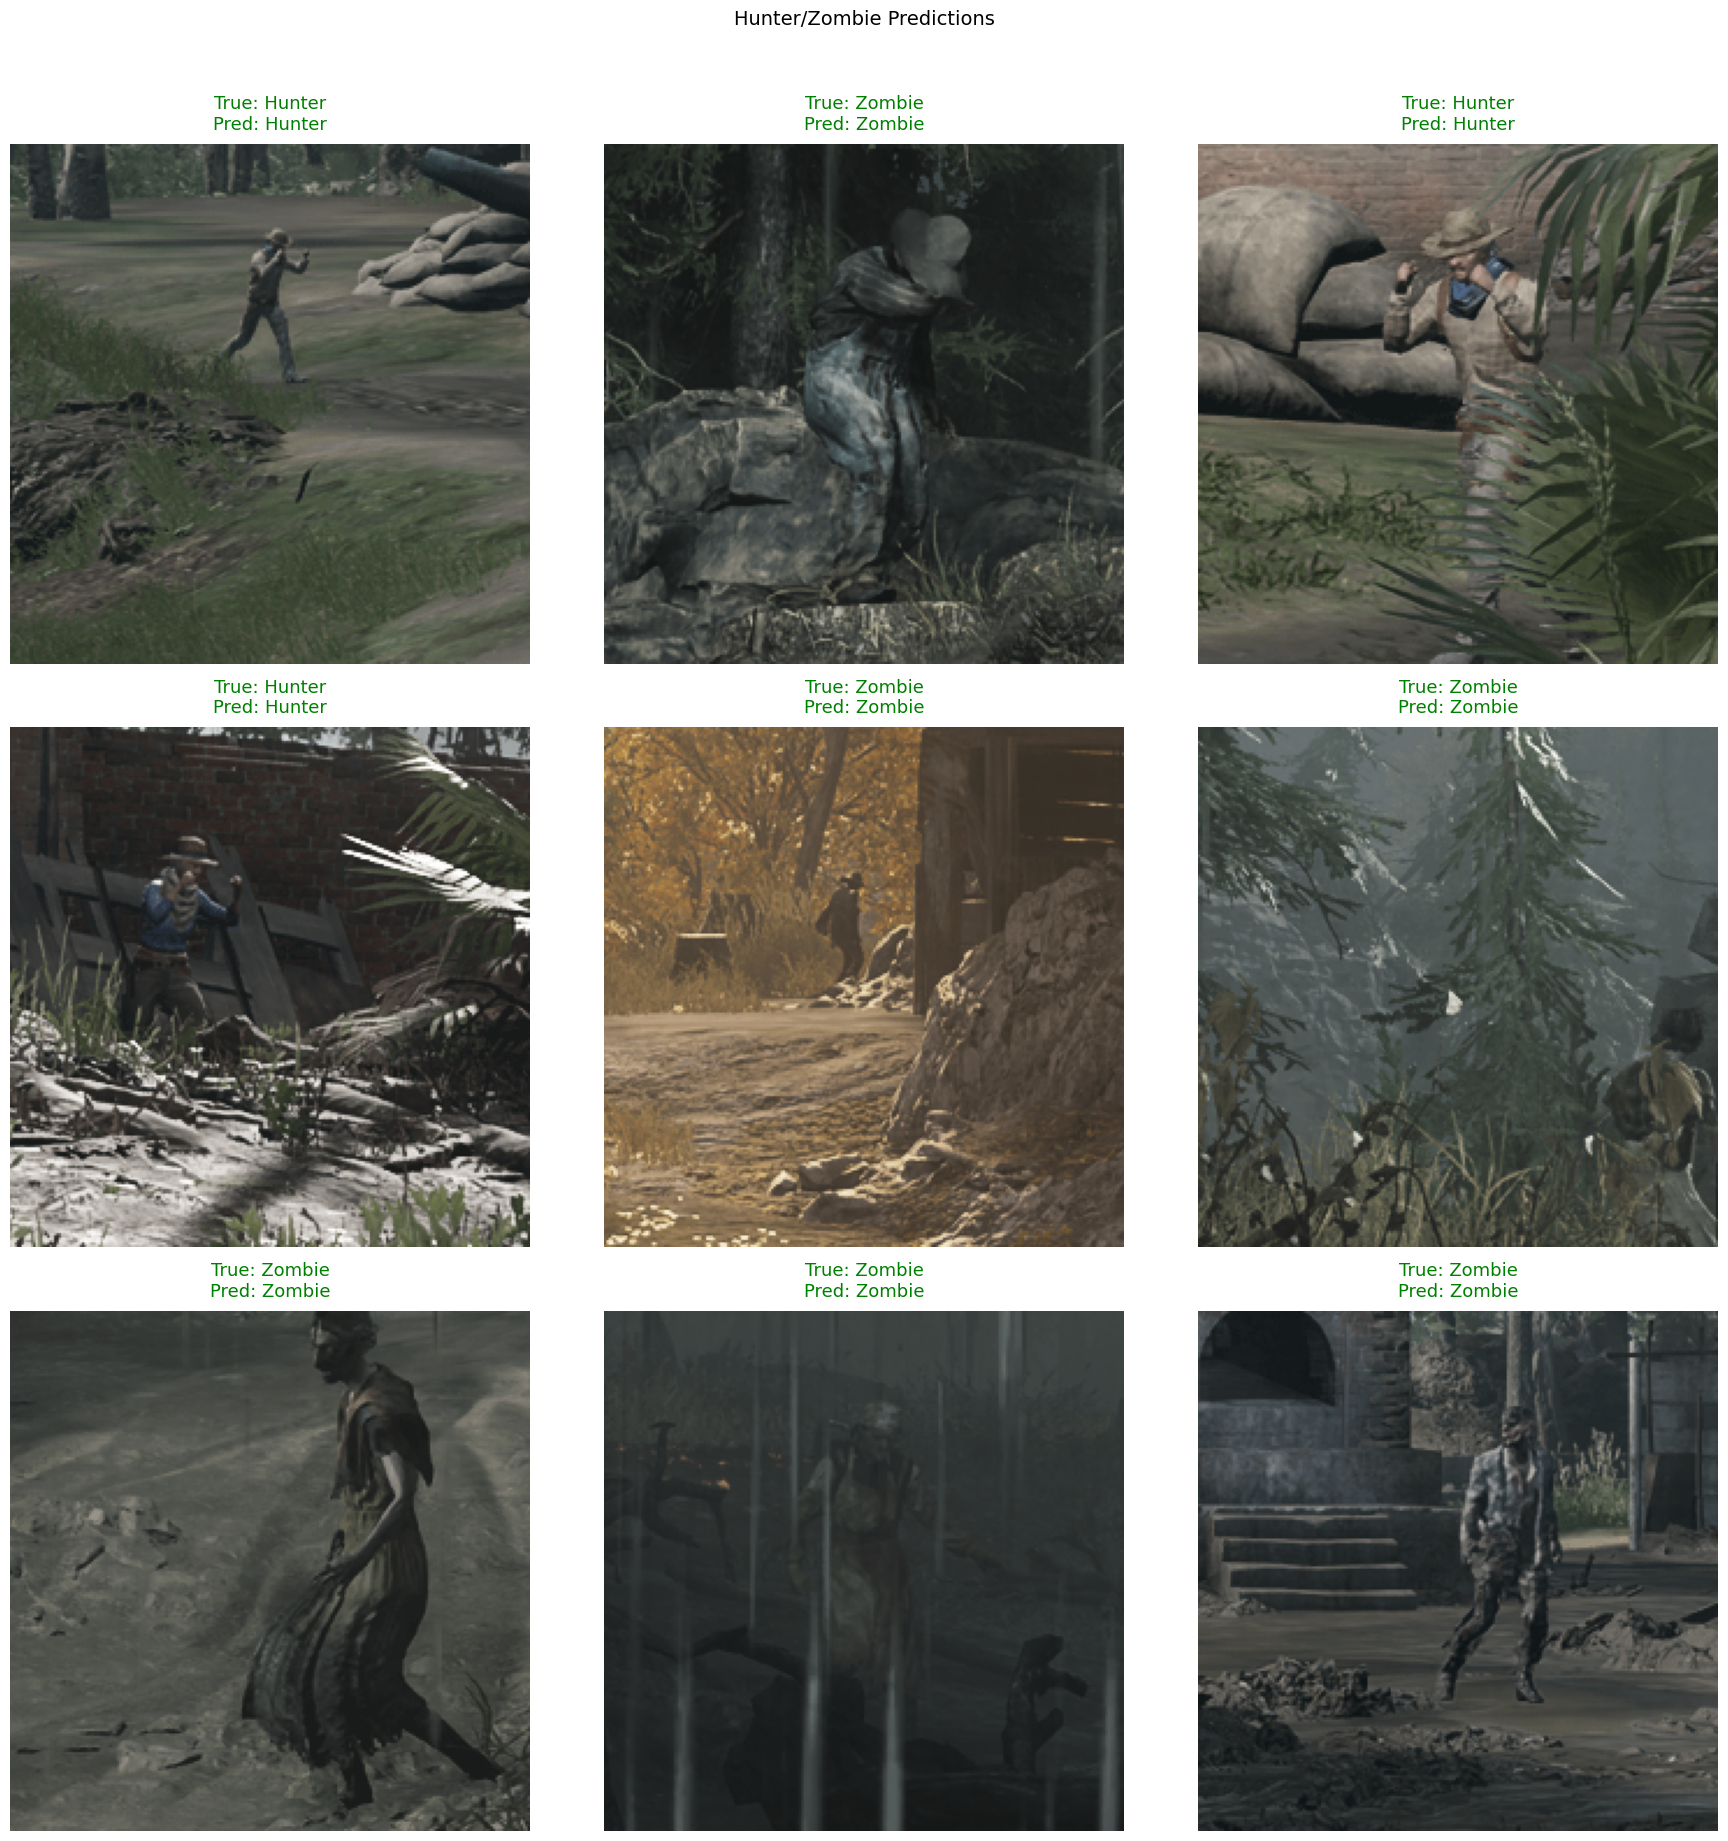

In [129]:
plt.figure(figsize=(18, 18))
subplot_idx = 1
# 2 batches from train_ds to get 16 images (8 per batch)
for batch_idx, (images, labels) in enumerate(train_ds.take(2)):
    for i in range(len(images)):

        image = images[i]
        true_label = labels[i].numpy()

        # need to add batch dimension since the model expects batch input
        image_batch = np.expand_dims(image.numpy(), axis=0)

        preprocessed_image = keras.applications.vgg16.preprocess_input(image_batch)
        features = conv_base.predict(preprocessed_image, verbose=0)
        prediction = test_model.predict(features, verbose=0)
        
        # class label
        predicted_class = "Zombie" if prediction[0][0] > 0.5 else "Hunter"
        # show img
        ax = plt.subplot(3, 3, subplot_idx)
        plt.imshow(image.numpy().astype("uint8"))
        plt.axis("off")
        
        title = f"True: {'Zombie' if true_label == 1 else 'Hunter'}\nPred: {predicted_class}"
        
        # color title
        is_correct = (prediction[0][0] > 0.5) == (true_label == 1)
        if is_correct:
            plt.title(title, fontsize=13, pad=10, color='green')
        else:
            plt.title(title, fontsize=13, pad=10, color='red')
        
        subplot_idx += 1
        
        # stop after 9 images
        if subplot_idx > 9:
            break
    
    if subplot_idx > 9:
        break

plt.suptitle("Hunter/Zombie Predictions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()